# Gunshot Detection — ML Training Notebook (Large Dataset Version)

**Dataset:** ~13,500 files across subfolders — uses memory-safe batch loading.


##  Install & Import Libraries

In [4]:
!pip install tensorflow librosa numpy scikit-learn matplotlib soundfile tqdm

import os
import warnings
import random
warnings.filterwarnings('ignore')

import numpy as np
import librosa
import librosa.display
import soundfile as sf
from tqdm import tqdm                          

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
%matplotlib inline

print('TensorFlow :', tf.__version__)
print('Librosa    :', librosa.__version__)
print('NumPy      :', np.__version__)

# Show how much RAM is available
import psutil
ram_gb = psutil.virtual_memory().available / (1024**3)
print(f'Available RAM : {ram_gb:.1f} GB')
if ram_gb < 4:
    print('WARNING: Less than 4GB RAM — use CACHE_TO_DISK = True in Cell 2')
else:
    print('RAM looks fine for this dataset.')

Defaulting to user installation because normal site-packages is not writeable
TensorFlow : 2.20.0
Librosa    : 0.11.0
NumPy      : 2.3.2
Available RAM : 24.4 GB
RAM looks fine for this dataset.


## Configuration


In [5]:

GUNSHOT_DIR    = 'dataset/Gunshot'      
BACKGROUND_DIR = 'dataset/Background'  
SAVE_DIR       = 'saved_model'


SAMPLE_RATE  = 22050
DURATION     = 1.0
N_MELS       = 64
HOP_LENGTH   = 512
N_FFT        = 1024

BATCH_SIZE   = 32    
EPOCHS       = 25

CACHE_TO_DISK = False
CACHE_DIR     = 'cache_spectrograms'

os.makedirs(SAVE_DIR, exist_ok=True)

VALID_EXT = {'.wav', '.mp3', '.ogg', '.flac'}

def count_files_recursive(root_folder):
    """Walk all subfolders and count audio files."""
    total = 0
    subfolders = []
    for dirpath, dirnames, filenames in os.walk(root_folder):
        audio_files = [f for f in filenames
                       if os.path.splitext(f)[1].lower() in VALID_EXT]
        if audio_files:
            subfolders.append((dirpath, len(audio_files)))
            total += len(audio_files)
    return total, subfolders

for label, folder in [('Gunshot', GUNSHOT_DIR), ('Background', BACKGROUND_DIR)]:
    if os.path.exists(folder):
        count, subs = count_files_recursive(folder)
        print(f'{label}: {count} files across {len(subs)} subfolders')
        # show first 3 subfolders as a preview
        for path, n in subs[:3]:
            print(f'    {path}  ({n} files)')
        if len(subs) > 3:
            print(f'    ... and {len(subs)-3} more subfolders')
    else:
        print(f'MISSING: {folder}')
    print()

Gunshot: 4773 files across 67 subfolders
    dataset/Gunshot\38s&ws_dot38_caliber  (503 files)
    dataset/Gunshot\AK-12  (123 files)
    dataset/Gunshot\AK-47  (97 files)
    ... and 64 more subfolders

Background: 8732 files across 10 subfolders
    dataset/Background\fold1  (873 files)
    dataset/Background\fold10  (837 files)
    dataset/Background\fold2  (888 files)
    ... and 7 more subfolders



## Scan All Subfolders, Build File List

Scanning all subfolders...
Gunshot files    : 4773
Background files : 8732
Background capped to 7159 (1.5x gunshot count — keeps classes balanced)

Final split:
  Total files  : 11932
  Train        : 9545
  Validation   : 2387

  Train  — Gunshot: 3837  Background: 5708
  Val    — Gunshot: 936    Background: 1451


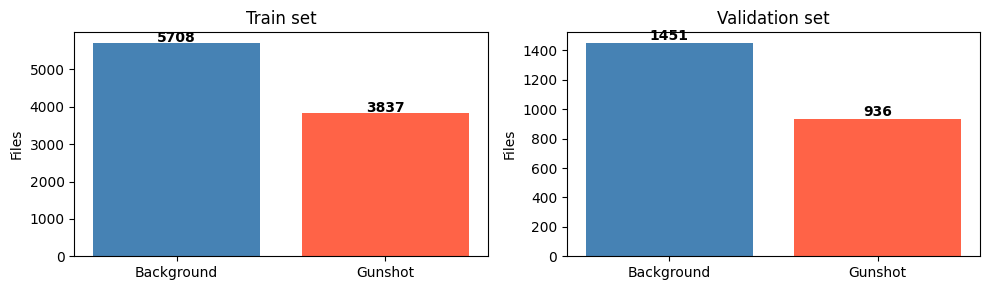

In [6]:
def collect_all_files(root_folder, label):
    
    file_list = []
    for dirpath, _, filenames in os.walk(root_folder):
        for filename in filenames:
            ext = os.path.splitext(filename)[1].lower()
            if ext in VALID_EXT:
                full_path = os.path.join(dirpath, filename)
                file_list.append((full_path, label))
    return file_list


print('Scanning all subfolders...')
gunshot_files    = collect_all_files(GUNSHOT_DIR,    label=1)
background_files = collect_all_files(BACKGROUND_DIR, label=0)

print(f'Gunshot files    : {len(gunshot_files)}')
print(f'Background files : {len(background_files)}')

MAX_BACKGROUND = int(len(gunshot_files) * 1.5)
if len(background_files) > MAX_BACKGROUND:
    random.seed(42)
    background_files = random.sample(background_files, MAX_BACKGROUND)
    print(f'Background capped to {len(background_files)} '
          f'(1.5x gunshot count — keeps classes balanced)')

all_files = gunshot_files + background_files
random.seed(42)
random.shuffle(all_files)

split_idx   = int(len(all_files) * 0.8)
train_files = all_files[:split_idx]
val_files   = all_files[split_idx:]

print(f'\nFinal split:')
print(f'  Total files  : {len(all_files)}')
print(f'  Train        : {len(train_files)}')
print(f'  Validation   : {len(val_files)}')

train_guns = sum(1 for _, l in train_files if l == 1)
val_guns   = sum(1 for _, l in val_files   if l == 1)
print(f'\n  Train  — Gunshot: {train_guns}  Background: {len(train_files)-train_guns}')
print(f'  Val    — Gunshot: {val_guns}    Background: {len(val_files)-val_guns}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, files, title in [
    (axes[0], train_files, 'Train set'),
    (axes[1], val_files,   'Validation set')
]:
    guns = sum(1 for _, l in files if l == 1)
    bgs  = len(files) - guns
    bars = ax.bar(['Background', 'Gunshot'], [bgs, guns],
                  color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Files')
    for bar, val in zip(bars, [bgs, guns]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Preview & Verify Audio Samples

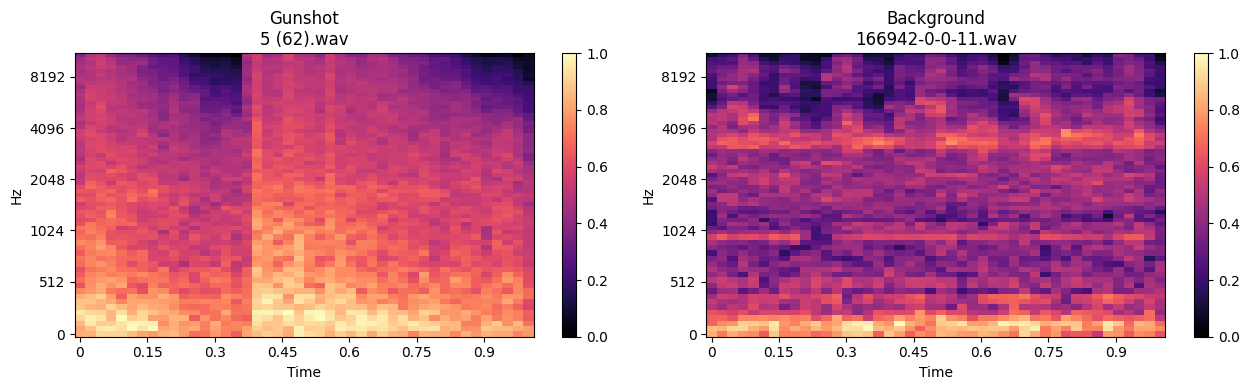

What to look for:
  Gunshot    → sharp bright vertical band (sudden burst of energy)
  Background → diffuse/random pattern with no clear spike

Running corruption check on 200 random files...
  Corrupt / unreadable: 0 out of 200
  Files look healthy!


In [7]:
# Core audio processing functions (used everywhere below) ─

def load_audio(filepath):
    """Load any audio format → mono numpy array at SAMPLE_RATE."""
    try:
        audio, _ = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
        return audio
    except Exception:
        return None


def fix_length(audio):
    """
    Force exactly 1 second of audio.
    Short clips → padded with silence.
    Long clips  → middle 1 second is taken.
    """
    target = int(SAMPLE_RATE * DURATION)
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)), mode='constant')
    elif len(audio) > target:
        start = (len(audio) - target) // 2
        audio = audio[start : start + target]
    return audio


def to_melspectrogram(audio):
    """
    Waveform → normalized mel-spectrogram.
    Output shape: (64, 44) — treated as a grayscale image by CNN.
    """
    mel    = librosa.feature.melspectrogram(
                y=audio, sr=SAMPLE_RATE,
                n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mn, mx = mel_db.min(), mel_db.max()
    if mx - mn == 0:
        return np.zeros_like(mel_db)
    return (mel_db - mn) / (mx - mn)


def file_to_spectrogram(filepath):
    """Full pipeline: filepath → ready spectrogram (or None if corrupt)."""
    audio = load_audio(filepath)
    if audio is None:
        return None
    audio = fix_length(audio)
    return to_melspectrogram(audio)


gun_fp = next(fp for fp, l in all_files if l == 1)
bg_fp  = next(fp for fp, l in all_files if l == 0)

gun_mel = file_to_spectrogram(gun_fp)
bg_mel  = file_to_spectrogram(bg_fp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, mel, title in [
    (axes[0], gun_mel, f'Gunshot\n{os.path.basename(gun_fp)}'),
    (axes[1], bg_mel,  f'Background\n{os.path.basename(bg_fp)}')
]:
    img = librosa.display.specshow(
            mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title)
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.show()

print('What to look for:')
print('  Gunshot    → sharp bright vertical band (sudden burst of energy)')
print('  Background → diffuse/random pattern with no clear spike')

print('\nRunning corruption check on 200 random files...')
sample_check = random.sample(all_files, min(200, len(all_files)))
corrupt = 0
for fp, _ in sample_check:
    if load_audio(fp) is None:
        corrupt += 1
print(f'  Corrupt / unreadable: {corrupt} out of 200')
if corrupt > 10:
    print('  WARNING: Many corrupt files — the generator will skip them automatically.')
else:
    print('  Files look healthy!')

## Memory-Safe Data Generator


In [8]:
class AudioDataGenerator(tf.keras.utils.Sequence):
    """
    Keras-compatible generator that loads audio files batch by batch.

    Instead of:
        load ALL 13,500 files → 10+ GB RAM → crash

    We do:
        load BATCH_SIZE files → process → yield → discard → repeat

    Keras calls __getitem__(batch_index) automatically during training.
    """

    def __init__(self, file_label_pairs, batch_size, shuffle=True):
        self.pairs      = file_label_pairs.copy()
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.on_epoch_end()   

    def __len__(self):
        """How many batches fit in this dataset."""
        return int(np.floor(len(self.pairs) / self.batch_size))

    def on_epoch_end(self):
        """Called after every epoch — reshuffle so batches differ each time."""
        if self.shuffle:
            random.shuffle(self.pairs)

    def __getitem__(self, batch_index):
        """
        Load and return one batch.
        batch_index = 0 → files 0..31
        batch_index = 1 → files 32..63
        etc.
        """
        start = batch_index * self.batch_size
        end   = start + self.batch_size
        batch_pairs = self.pairs[start:end]

        X_batch, y_batch = [], []

        for filepath, label in batch_pairs:
            mel = file_to_spectrogram(filepath)
            if mel is None:
                
                mel = np.zeros((N_MELS, 44))
            X_batch.append(mel)
            y_batch.append(label)

        X_batch = np.array(X_batch)[..., np.newaxis].astype(np.float32)
        y_batch = np.array(y_batch).astype(np.float32)

        return X_batch, y_batch


train_gen = AudioDataGenerator(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = AudioDataGenerator(val_files,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train generator : {len(train_gen)} batches × {BATCH_SIZE} files = '
      f'~{len(train_gen)*BATCH_SIZE} files/epoch')
print(f'Val generator   : {len(val_gen)} batches × {BATCH_SIZE} files')

print('\nTesting first batch...')
X_test_batch, y_test_batch = train_gen[0]
print(f'  X batch shape : {X_test_batch.shape}  (batch, height, width, channel)')
print(f'  y batch shape : {y_test_batch.shape}')
print(f'  Labels in batch: {np.unique(y_test_batch, return_counts=True)}')
print('Generator working correctly!')

Train generator : 298 batches × 32 files = ~9536 files/epoch
Val generator   : 74 batches × 32 files

Testing first batch...
  X batch shape : (32, 64, 44, 1)  (batch, height, width, channel)
  y batch shape : (32,)
  Labels in batch: (array([0., 1.], dtype=float32), array([19, 13]))
Generator working correctly!


## Build the CNN Model

In [9]:
def build_model():
    """
    CNN that reads mel-spectrograms as images.

    Input  : (64, 44, 1)  — spectrogram image
    Output : single value 0.0 → 1.0
             > 0.5 = gunshot detected
             < 0.5 = background

    Each block:
      Conv2D       — learns patterns (edges, shapes, spikes)
      BatchNorm    — stabilizes training
      MaxPooling   — shrinks feature map, reduces computation
      Dropout      — randomly disables neurons to prevent overfitting
    """
    
    INPUT_SHAPE = (N_MELS, 44, 1)

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),   # collapses spatial dims → 1D
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')   # 0 = background, 1 = gunshot
    ])

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy',
                     tf.keras.metrics.Precision(name='precision'),
                     tf.keras.metrics.Recall(name='recall')]
    )
    return model


model = build_model()
model.summary()

test_out = model.predict(X_test_batch, verbose=0)
print(f'\nUntrained model output range: {test_out.min():.3f} → {test_out.max():.3f}')
print('(Should be random values near 0.5 before training — that is expected)')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 44, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 44, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 22, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 22, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 22, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 11, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 11, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 5, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 8, 5, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             2

 Total params: 455,809 (1.74 MB)

 Trainable params: 454,849 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)


Untrained model output range: 0.502 → 0.504
(Should be random values near 0.5 before training — that is expected)


## Train the Model


In [10]:
MODEL_PATH = os.path.join(SAVE_DIR, 'gunshot_model.h5')

early_stop = callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

checkpoint = callbacks.ModelCheckpoint(
    filepath       = MODEL_PATH,
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6,
    verbose  = 1
)

print(f'Training on {len(train_files)} files, validating on {len(val_files)} files')
print(f'Each epoch = {len(train_gen)} batches of {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS} (EarlyStopping may end it sooner)\n')

history = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = [early_stop, checkpoint, reduce_lr]
)

print(f'\nTraining complete!')
print(f'Best model saved to: {MODEL_PATH}')

Training on 9545 files, validating on 2387 files
Each epoch = 298 batches of 32
Max epochs : 25 (EarlyStopping may end it sooner)

Epoch 1/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8745 - loss: 0.2905 - precision: 0.8445 - recall: 0.8351
Epoch 1: val_accuracy improved from None to 0.72382, saving model to saved_model\gunshot_model.h5



Epoch 1: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 588s 2s/step - accuracy: 0.9134 - loss: 0.2190 - precision: 0.9028 - recall: 0.8792 - val_accuracy: 0.7238 - val_loss: 0.5455 - val_precision: 0.5975 - val_recall: 0.8927 - learning_rate: 0.0010
Epoch 2/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9341 - loss: 0.1563 - precision: 0.9271 - recall: 0.9079
Epoch 2: val_accuracy improved from 0.72382 to 0.83784, saving model to saved_model\gunshot_model.h5



Epoch 2: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step - accuracy: 0.9394 - loss: 0.1438 - precision: 0.9329 - recall: 0.9149 - val_accuracy: 0.8378 - val_loss: 0.4181 - val_precision: 0.7214 - val_recall: 0.9512 - learning_rate: 0.0010
Epoch 3/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9613 - loss: 0.1106 - precision: 0.9541 - recall: 0.9489
Epoch 3: val_accuracy improved from 0.83784 to 0.94552, saving model to saved_model\gunshot_model.h5



Epoch 3: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 453s 1s/step - accuracy: 0.9584 - loss: 0.1109 - precision: 0.9483 - recall: 0.9481 - val_accuracy: 0.9455 - val_loss: 0.1340 - val_precision: 0.9441 - val_recall: 0.9144 - learning_rate: 0.0010
Epoch 4/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.9580 - loss: 0.1130 - precision: 0.9505 - recall: 0.9438
Epoch 4: val_accuracy improved from 0.94552 to 0.96495, saving model to saved_model\gunshot_model.h5



Epoch 4: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9624 - loss: 0.1039 - precision: 0.9559 - recall: 0.9502 - val_accuracy: 0.9649 - val_loss: 0.0928 - val_precision: 0.9861 - val_recall: 0.9231 - learning_rate: 0.0010
Epoch 5/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9659 - loss: 0.0869 - precision: 0.9544 - recall: 0.9595
Epoch 5: val_accuracy improved from 0.96495 to 0.97508, saving model to saved_model\gunshot_model.h5



Epoch 5: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.9665 - loss: 0.0853 - precision: 0.9582 - recall: 0.9585 - val_accuracy: 0.9751 - val_loss: 0.0586 - val_precision: 0.9557 - val_recall: 0.9816 - learning_rate: 0.0010
Epoch 6/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9689 - loss: 0.0852 - precision: 0.9627 - recall: 0.9601
Epoch 6: val_accuracy did not improve from 0.97508
298/298 ━━━━━━━━━━━━━━━━━━━━ 356s 1s/step - accuracy: 0.9707 - loss: 0.0833 - precision: 0.9642 - recall: 0.9630 - val_accuracy: 0.9337 - val_loss: 0.1621 - val_precision: 0.8573 - val_recall: 0.9957 - learning_rate: 0.0010
Epoch 7/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9736 - loss: 0.0726 - precision: 0.9684 - recall: 0.9658
Epoch 7: val_accuracy did not improve from 0.97508
298/298 ━━━━━━━━━━━━━━━━━━━━ 382s 1s/step - accuracy: 0.9737 - loss: 0.0742 - precision: 0.9681 - recall: 0.9663 - val_accuracy: 0.9713 - val_


Epoch 9: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.9802 - loss: 0.0555 - precision: 0.9745 - recall: 0.9763 - val_accuracy: 0.9840 - val_loss: 0.0401 - val_precision: 0.9692 - val_recall: 0.9902 - learning_rate: 5.0000e-04
Epoch 10/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9843 - loss: 0.0437 - precision: 0.9797 - recall: 0.9814
Epoch 10: val_accuracy did not improve from 0.98395
298/298 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.9840 - loss: 0.0452 - precision: 0.9784 - recall: 0.9817 - val_accuracy: 0.9738 - val_loss: 0.0595 - val_precision: 0.9388 - val_recall: 0.9978 - learning_rate: 5.0000e-04
Epoch 11/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9873 - loss: 0.0374 - precision: 0.9806 - recall: 0.9876
Epoch 11: val_accuracy did not improve from 0.98395
298/298 ━━━━━━━━━━━━━━━━━━━━ 226s 759ms/step - accuracy: 0.9862 - loss: 0.0383 - precision: 0.9803 - recall: 0.9854 - val_accur


Epoch 13: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 267s 897ms/step - accuracy: 0.9895 - loss: 0.0304 - precision: 0.9862 - recall: 0.9877 - val_accuracy: 0.9894 - val_loss: 0.0313 - val_precision: 0.9787 - val_recall: 0.9946 - learning_rate: 2.5000e-04
Epoch 14/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9913 - loss: 0.0250 - precision: 0.9881 - recall: 0.9905
Epoch 14: val_accuracy did not improve from 0.98944
298/298 ━━━━━━━━━━━━━━━━━━━━ 217s 729ms/step - accuracy: 0.9894 - loss: 0.0297 - precision: 0.9849 - recall: 0.9888 - val_accuracy: 0.9671 - val_loss: 0.0896 - val_precision: 0.9324 - val_recall: 0.9870 - learning_rate: 2.5000e-04
Epoch 15/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9894 - loss: 0.0277 - precision: 0.9853 - recall: 0.9882
Epoch 15: val_accuracy did not improve from 0.98944
298/298 ━━━━━━━━━━━━━━━━━━━━ 219s 733ms/step - accuracy: 0.9896 - loss: 0.0270 - precision: 0.9854 - recall: 0.9888 -


Epoch 16: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 268s 753ms/step - accuracy: 0.9897 - loss: 0.0253 - precision: 0.9865 - recall: 0.9880 - val_accuracy: 0.9911 - val_loss: 0.0231 - val_precision: 0.9829 - val_recall: 0.9946 - learning_rate: 2.5000e-04
Epoch 17/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 627ms/step - accuracy: 0.9945 - loss: 0.0174 - precision: 0.9930 - recall: 0.9933
Epoch 17: val_accuracy did not improve from 0.99113
298/298 ━━━━━━━━━━━━━━━━━━━━ 259s 742ms/step - accuracy: 0.9926 - loss: 0.0208 - precision: 0.9904 - recall: 0.9911 - val_accuracy: 0.9818 - val_loss: 0.0507 - val_precision: 0.9564 - val_recall: 0.9989 - learning_rate: 2.5000e-04
Epoch 18/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.9921 - loss: 0.0204 - precision: 0.9892 - recall: 0.9909
Epoch 18: val_accuracy did not improve from 0.99113
298/298 ━━━━━━━━━━━━━━━━━━━━ 217s 728ms/step - accuracy: 0.9915 - loss: 0.0217 - precision: 0.9891 - recall: 0.9898 -


Epoch 21: finished saving model to saved_model\gunshot_model.h5
298/298 ━━━━━━━━━━━━━━━━━━━━ 229s 732ms/step - accuracy: 0.9951 - loss: 0.0149 - precision: 0.9935 - recall: 0.9943 - val_accuracy: 0.9954 - val_loss: 0.0144 - val_precision: 0.9914 - val_recall: 0.9967 - learning_rate: 1.2500e-04
Epoch 22/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.9948 - loss: 0.0129 - precision: 0.9928 - recall: 0.9941
Epoch 22: val_accuracy did not improve from 0.99535
298/298 ━━━━━━━━━━━━━━━━━━━━ 262s 731ms/step - accuracy: 0.9943 - loss: 0.0146 - precision: 0.9932 - recall: 0.9927 - val_accuracy: 0.9924 - val_loss: 0.0177 - val_precision: 0.9850 - val_recall: 0.9957 - learning_rate: 1.2500e-04
Epoch 23/25
298/298 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9950 - loss: 0.0148 - precision: 0.9923 - recall: 0.9953
Epoch 23: val_accuracy did not improve from 0.99535
298/298 ━━━━━━━━━━━━━━━━━━━━ 431s 1s/step - accuracy: 0.9951 - loss: 0.0139 - precision: 0.9935 - recall: 0.9943 - val_a

## Evaluate & Plot Results

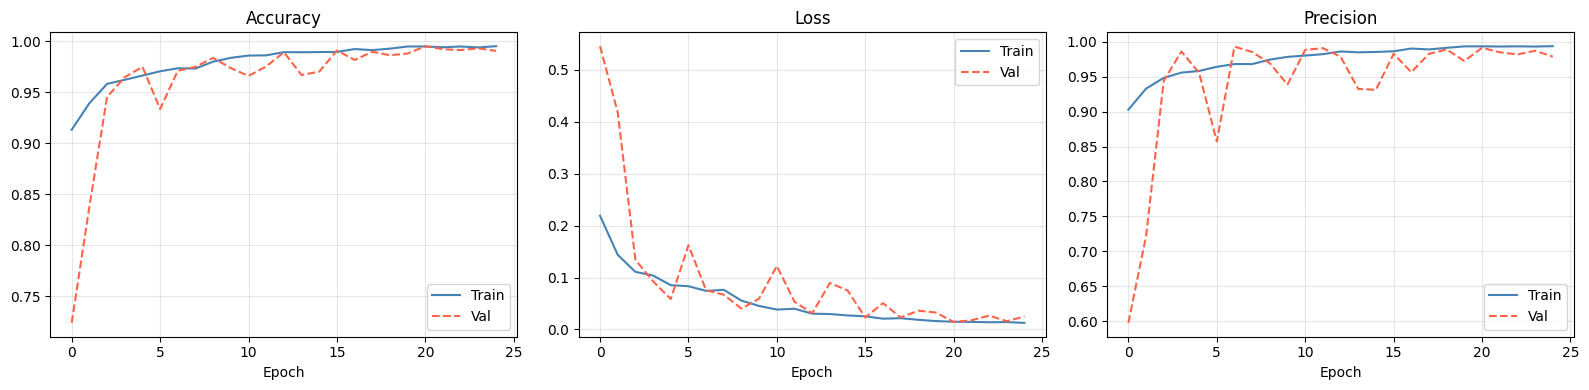

Running predictions on validation set...


100%|██████████████████████████████████████████████████████████████████████████████████| 74/74 [00:49<00:00,  1.50it/s]


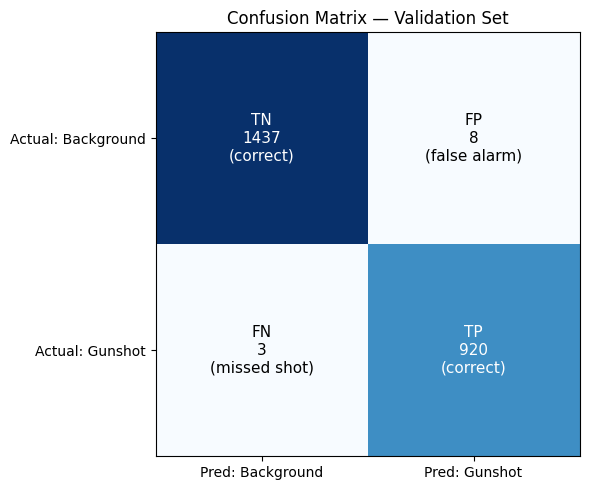

              precision    recall  f1-score   support

  Background       1.00      0.99      1.00      1445
     Gunshot       0.99      1.00      0.99       923

    accuracy                           1.00      2368
   macro avg       0.99      1.00      1.00      2368
weighted avg       1.00      1.00      1.00      2368

  Gunshot Precision : 99.1%  — of every 100 detections, 99 are real gunshots
  Gunshot Recall    : 99.7%  — of every 100 actual gunshots, 100 are caught
  False Alarm Rate  : 0.6%  — of every 100 background clips, 1 trigger falsely

  Model is ready for Pi deployment!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('loss',      'val_loss',      'Loss'),
    ('precision', 'val_precision', 'Precision'),
]
for ax, (train_m, val_m, title) in zip(axes, metrics):
    if train_m in history.history:
        ax.plot(history.history[train_m], label='Train', color='steelblue')
    if val_m in history.history:
        ax.plot(history.history[val_m],   label='Val',   color='tomato', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_plot.png', dpi=150)
plt.show()

print('Running predictions on validation set...')
y_pred_all = []
y_true_all = []

for i in tqdm(range(len(val_gen))):
    X_b, y_b       = val_gen[i]
    preds           = model.predict(X_b, verbose=0)
    y_pred_all.extend((preds > 0.5).astype(int).flatten())
    y_true_all.extend(y_b.astype(int))

y_pred_all = np.array(y_pred_all)
y_true_all = np.array(y_true_all)

cm = confusion_matrix(y_true_all, y_pred_all)

tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred: Background','Pred: Gunshot'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Actual: Background','Actual: Gunshot'])
ax.set_title('Confusion Matrix — Validation Set')

cell_labels = [
    [f'TN\n{tn}\n(correct)',     f'FP\n{fp}\n(false alarm)'],
    [f'FN\n{fn}\n(missed shot)', f'TP\n{tp}\n(correct)']
]
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, cell_labels[i][j], ha='center', va='center',
                color=color, fontsize=11)
plt.tight_layout()
plt.show()

print(classification_report(y_true_all, y_pred_all,
      target_names=['Background', 'Gunshot']))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
far       = fp / (fp + tn) if (fp + tn) > 0 else 0  

print(f'  Gunshot Precision : {precision:.1%}  '
      f'— of every 100 detections, {precision*100:.0f} are real gunshots')
print(f'  Gunshot Recall    : {recall:.1%}  '
      f'— of every 100 actual gunshots, {recall*100:.0f} are caught')
print(f'  False Alarm Rate  : {far:.1%}  '
      f'— of every 100 background clips, {far*100:.0f} trigger falsely')
print()

if precision > 0.85 and recall > 0.85:
    print('  Model is ready for Pi deployment!')
elif recall < 0.80:
    print('  Recall is low — model is missing real gunshots.')
    print('  Try: train for more epochs, or lower the detection threshold below 0.5')
elif precision < 0.80:
    print('  Precision is low — too many false alarms.')
    print('  Try: raise detection threshold above 0.5 (e.g. 0.7)')

## Convert to TFLite for Raspberry Pi

In [12]:
TFLITE_PATH = os.path.join(SAVE_DIR, 'gunshot_model.tflite')

print('Loading best saved model...')
best_model = tf.keras.models.load_model(MODEL_PATH)

print('Converting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

# Quantization: reduces model size ~4x, runs faster on Pi
# Tiny accuracy loss — worth it for embedded deployment
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

h5_kb     = os.path.getsize(MODEL_PATH)  / 1024
tflite_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f'\nOriginal .h5     : {h5_kb:.0f} KB')
print(f'TFLite model     : {tflite_kb:.0f} KB  ({100*tflite_kb/h5_kb:.0f}% of original)')

# Sanity check: run the TFLite model on one sample
print('\nSanity check — running one sample through TFLite model...')
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

sample_mel = file_to_spectrogram(gunshot_files[0][0])
sample_inp = sample_mel[np.newaxis, ..., np.newaxis].astype(np.float32)

interpreter.set_tensor(inp[0]['index'], sample_inp)
interpreter.invoke()
result = interpreter.get_tensor(out[0]['index'])[0][0]

print(f'  Test gunshot file → confidence: {result:.4f}')
print(f'  Prediction: {"GUNSHOT" if result > 0.5 else "background"}  '
      f'({"correct" if result > 0.5 else "WRONG"})')

print(f'\nDone! Hand your teammate:')
print(f'  {TFLITE_PATH}')
print()
print('Tell them the detection threshold is 0.5 —')
print('if model output > 0.5, it is a gunshot.')

Loading best saved model...


Converting to TFLite...
INFO:tensorflow:Assets written to: C:\Users\Pradeep\AppData\Local\Temp\tmpz_i13kj2\assets


INFO:tensorflow:Assets written to: C:\Users\Pradeep\AppData\Local\Temp\tmpz_i13kj2\assets


Saved artifact at 'C:\Users\Pradeep\AppData\Local\Temp\tmpz_i13kj2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 44, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1573582710992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573582711568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223529552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223526480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573582709648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223529168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223527440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223529360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223528784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1573223528016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  157322